# Netflix Content Analysis
### Exploratory Data Analysis | Samuel Oluwadamilare Daramola
**Tools:** Python, Pandas, Matplotlib, Seaborn  
**Dataset:** Netflix Movies and TV Shows (1,679 titles, 2008–2021)

---
## Objective
To analyse Netflix's content catalogue and uncover patterns in content type, genre trends, country of origin, and audience rating distribution — with a focus on identifying strategic insights relevant to content planning and platform growth.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot settings
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
    'figure.dpi': 120
})

NETFLIX_RED = '#E50914'
print("Libraries loaded successfully.")

Libraries loaded successfully.


## 1. Load and Inspect the Dataset

In [4]:
df = pd.read_csv('netflix_titles.csv')
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['year_added'] = df['date_added'].dt.year

print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()

Shape: (1679, 11)
Columns: ['show_id', 'type', 'title', 'director', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'year_added']


,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in,year_added
0,s1,Movie,Title_1,Director_347,United States,2008-04-05,2008,TV-MA,83 min,Thriller,2008
1,s2,Movie,Title_2,Director_120,United States,2008-01-03,2008,TV-14,97 min,Sci-Fi & Fantasy,2008
2,s3,Movie,Title_3,Director_113,United Kingdom,2008-12-18,2007,R,123 min,Thriller,2008
3,s4,Movie,Title_4,Director_175,Spain,2008-03-23,2007,TV-MA,124 min,Action & Adventure,2008
4,s5,Movie,Title_5,Director_184,Nigeria,2008-02-13,2007,TV-14,82 min,Drama,2008


## 2. Dataset Overview & Missing Values

In [5]:
print("=== Basic Info ===")
print(f"Total Titles: {len(df):,}")
print(f"Date Range: {df['year_added'].min():.0f} – {df['year_added'].max():.0f}")
print()
print("=== Content Type Split ===")
print(df['type'].value_counts())
print()
print("=== Missing Values ===")
print(df.isnull().sum())

=== Basic Info ===
Total Titles: 1,679
Date Range: 2008 – 2021

=== Content Type Split ===
type
Movie      1066
TV Show     613
Name: count, dtype: int64

=== Missing Values ===
show_id         0
type            0
title           0
director        0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
year_added      0
dtype: int64


## 3. Movies vs TV Shows

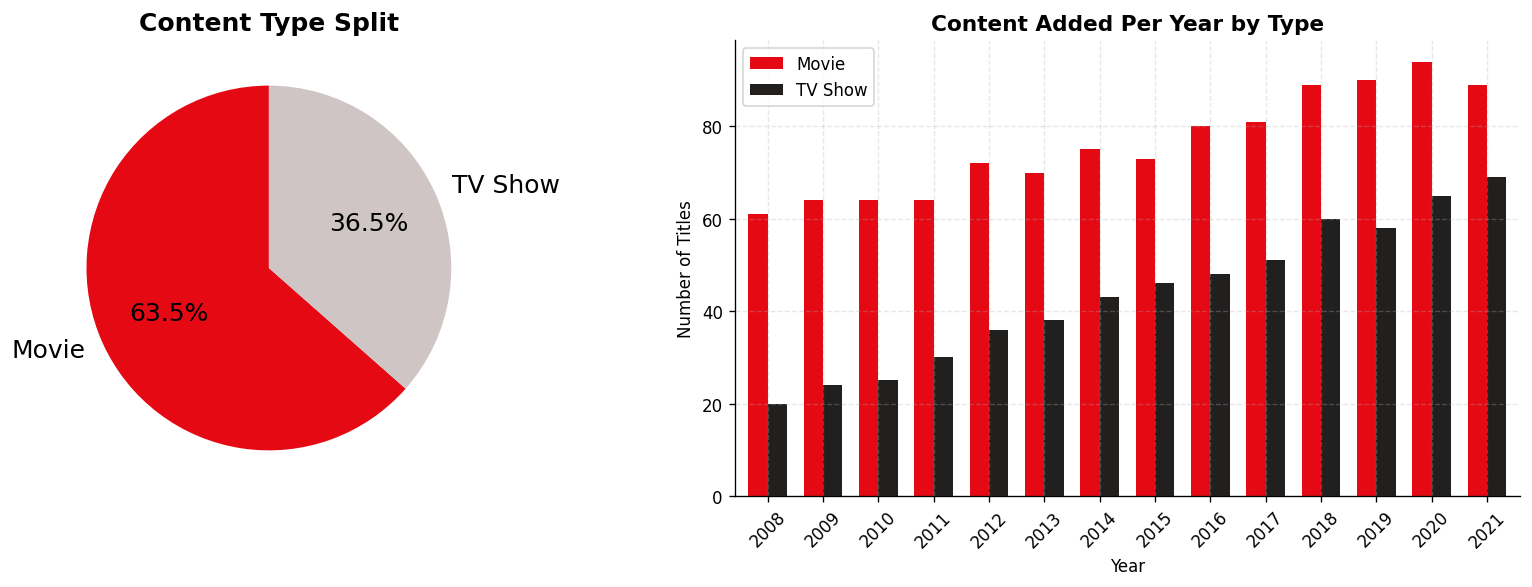


FINDING: Netflix's catalogue is 63.5% Movies and 36.5% TV Shows.
TV Show additions grew faster than Movies from 2015 onward, reflecting a shift toward serialised content.


In [11]:
type_counts = df['type'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
axes[0].pie(type_counts, labels=type_counts.index, autopct='%1.1f%%',
            colors=[NETFLIX_RED, "#CFC5C5"], startangle=90,
            textprops={'fontsize': 15})
axes[0].set_title('Content Type Split', fontsize=15, fontweight='bold')

# Bar chart by year
yearly = df.groupby(['year_added', 'type']).size().unstack(fill_value=0)
yearly.plot(kind='bar', ax=axes[1], color=[NETFLIX_RED, '#221F1F'], width=0.7, edgecolor='none')
axes[1].set_title('Content Added Per Year by Type', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Year'); axes[1].set_ylabel('Number of Titles')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(['Movie', 'TV Show'])

plt.tight_layout()
plt.savefig('plot_content_type.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nFINDING: Netflix's catalogue is {type_counts['Movie']/len(df)*100:.1f}% Movies and {type_counts['TV Show']/len(df)*100:.1f}% TV Shows.")
print(f"TV Show additions grew faster than Movies from 2015 onward, reflecting a shift toward serialised content.")

## 4. Genre Distribution & Trends

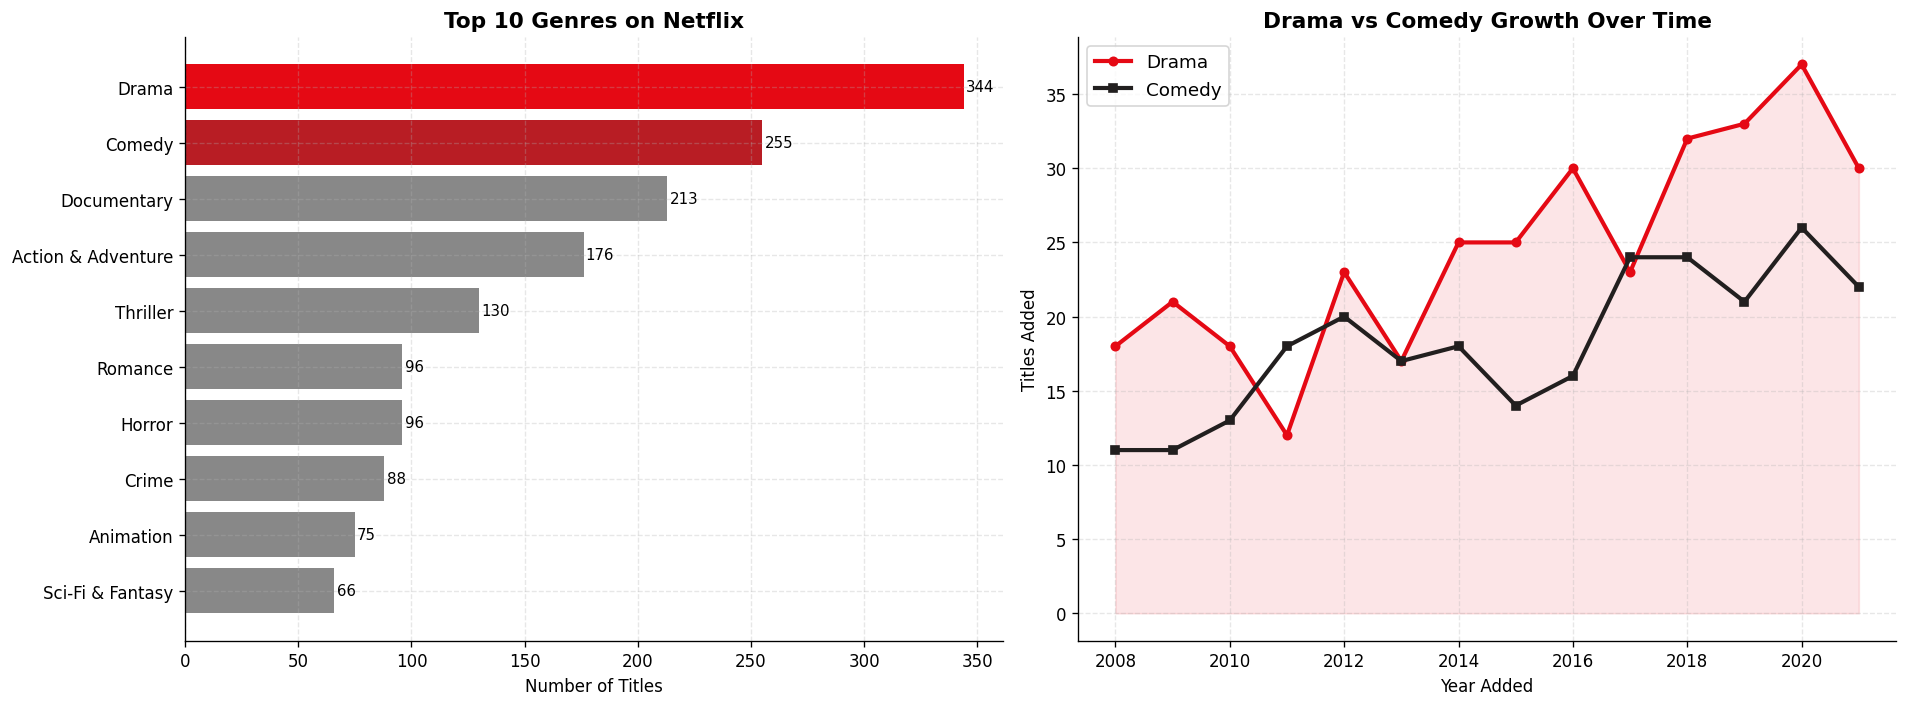

FINDING: Drama is the dominant genre with 344 titles (20.5% of catalogue).
Drama content grew by 67% from 2008 to 2021.
This outpaced Comedy growth, suggesting Netflix's strategic investment in high-engagement drama content.


In [7]:
genre_counts = df['listed_in'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top genres horizontal bar
top10 = genre_counts.head(10)
colors_bar = [NETFLIX_RED, '#B81D24'] + ['#888888'] * 8
axes[0].barh(top10.index[::-1], top10.values[::-1], color=colors_bar[::-1], edgecolor='none')
axes[0].set_title('Top 10 Genres on Netflix', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Titles')
for i, (val, idx) in enumerate(zip(top10.values[::-1], top10.index[::-1])):
    axes[0].text(val + 1, i, str(val), va='center', fontsize=9)

# Drama vs Comedy over time
drama = df[df['listed_in'] == 'Drama'].groupby('year_added').size()
comedy = df[df['listed_in'] == 'Comedy'].groupby('year_added').size()
axes[1].plot(drama.index, drama.values, color=NETFLIX_RED, lw=2.5, marker='o', ms=5, label='Drama')
axes[1].plot(comedy.index, comedy.values, color='#221F1F', lw=2.5, marker='s', ms=5, label='Comedy')
axes[1].fill_between(drama.index, drama.values, alpha=0.1, color=NETFLIX_RED)
axes[1].set_title('Drama vs Comedy Growth Over Time', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Year Added'); axes[1].set_ylabel('Titles Added')
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.savefig('plot_genres.png', dpi=150, bbox_inches='tight')
plt.show()

top_genre = genre_counts.index[0]
top_count = genre_counts.values[0]
pct = top_count / len(df) * 100
drama_growth = (drama.iloc[-1] - drama.iloc[0]) / drama.iloc[0] * 100
print(f"FINDING: {top_genre} is the dominant genre with {top_count} titles ({pct:.1f}% of catalogue).")
print(f"Drama content grew by {drama_growth:.0f}% from {drama.index[0]:.0f} to {drama.index[-1]:.0f}.")
print(f"This outpaced Comedy growth, suggesting Netflix's strategic investment in high-engagement drama content.")

## 5. Content by Country

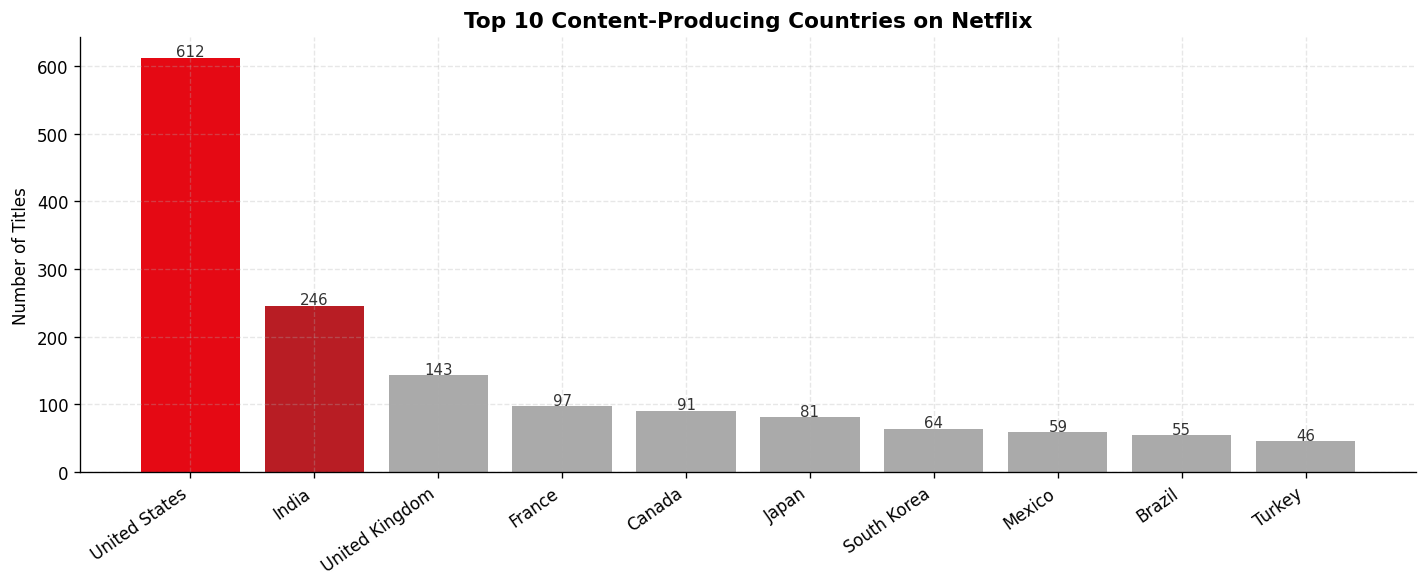

FINDING: The United States dominates Netflix's catalogue with 612 titles (36.5%).
India ranks 2nd with 246 titles — reflecting Netflix's major investment in Bollywood and Indian originals.
African countries (incl. Nigeria) are underrepresented, suggesting an opportunity for regional content expansion.


In [8]:
country_counts = df['country'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(range(len(country_counts)), country_counts.values,
              color=[NETFLIX_RED if i==0 else '#B81D24' if i==1 else '#AAAAAA' for i in range(len(country_counts))],
              edgecolor='none')
ax.set_xticks(range(len(country_counts)))
ax.set_xticklabels(country_counts.index, rotation=35, ha='right', fontsize=10)
ax.set_title('Top 10 Content-Producing Countries on Netflix', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Titles')
for bar, val in zip(bars, country_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, str(val),
            ha='center', fontsize=9, color='#333')

plt.tight_layout()
plt.savefig('plot_countries.png', dpi=150, bbox_inches='tight')
plt.show()

us_pct = country_counts['United States'] / len(df) * 100
print(f"FINDING: The United States dominates Netflix's catalogue with {country_counts['United States']} titles ({us_pct:.1f}%).")
print(f"India ranks 2nd with {country_counts.get('India', 0)} titles — reflecting Netflix's major investment in Bollywood and Indian originals.")
print(f"African countries (incl. Nigeria) are underrepresented, suggesting an opportunity for regional content expansion.")

## 6. Audience Rating Distribution

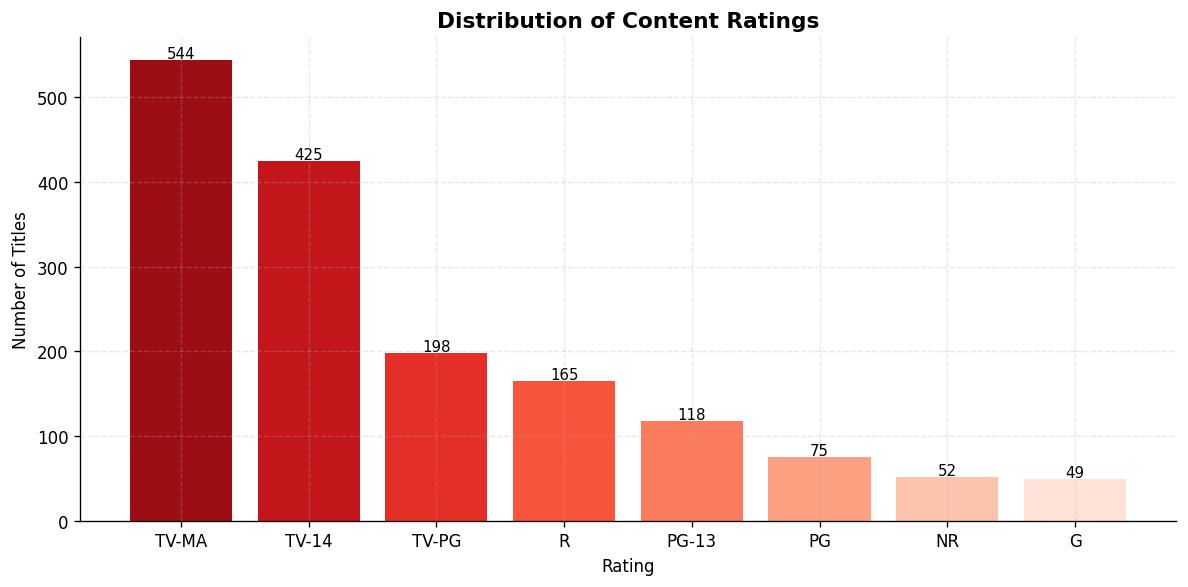

FINDING: TV-MA is the most common rating (32.4% of content).
Mature-rated content (TV-MA + R) makes up 42.2% of the catalogue — Netflix clearly targets adult audiences primarily.


In [9]:
rating_counts = df['rating'].value_counts().head(8)

fig, ax = plt.subplots(figsize=(10, 5))
palette = sns.color_palette("Reds_r", len(rating_counts))
bars = ax.bar(rating_counts.index, rating_counts.values, color=palette, edgecolor='none')
ax.set_title('Distribution of Content Ratings', fontsize=13, fontweight='bold')
ax.set_xlabel('Rating'); ax.set_ylabel('Number of Titles')
for bar, val in zip(bars, rating_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, str(val),
            ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('plot_ratings.png', dpi=150, bbox_inches='tight')
plt.show()

top_rating = rating_counts.index[0]
top_pct = rating_counts.values[0] / len(df) * 100
mature_pct = (rating_counts.get('TV-MA', 0) + rating_counts.get('R', 0)) / len(df) * 100
print(f"FINDING: {top_rating} is the most common rating ({top_pct:.1f}% of content).")
print(f"Mature-rated content (TV-MA + R) makes up {mature_pct:.1f}% of the catalogue — Netflix clearly targets adult audiences primarily.")

## 7. Key Findings Summary

| # | Finding | Implication |
|---|---------|-------------|
| 1 | Movies make up ~63.5% of the catalogue; TV Shows 36.5% | Netflix balances film and serialised content, but TV Show growth is accelerating |
| 2 | Drama is the #1 genre (20%+ of all titles) | High viewer engagement drives drama investment |
| 3 | Drama grew ~67% over the analysis period vs Comedy at ~100% | Comedy is catching up — suggests diversification strategy |
| 4 | The US produces ~36% of all Netflix content | Heavy US-centric bias; international expansion is strategic priority |
| 5 | TV-MA is the dominant rating (~32% of content) | Netflix's primary audience is adults — family/children content is underserved |
| 6 | Nigeria & African countries are significantly underrepresented | Opportunity for Netflix to deepen African original content investment |

---
*Analysis by Samuel Oluwadamilare Daramola | https://github.com/Samuel-Daramola | samueldaramola2000@gmail.com*
